# MicroProyecto: Clasificación de Tumores Cerebrales con CNNs

**Curso:** Técnicas de Deep Learning  

**Dataset:** Brain Tumor MRI Scans (Kaggle) — 7 023 imágenes, 4 clases  

**Framework:** PyTorch

**Grupo:** 24

**Integrantes:** Jaime Rodriguez, Juan Martin Santos, Yezid Garcia

---

## Descripción del Problema

Las resonancias magnéticas (MRI) generan volúmenes 3D del tejido cerebral. Diagnosticar el tipo de tumor a partir de esos volúmenes es una tarea costosa computacionalmente, así que simplificamos el problema trabajando con **cortes 2D individuales** extraídos del volumen. Esto convierte el problema médico en una tarea estándar de clasificación de imágenes.

El modelo debe distinguir entre cuatro categorías:

| Clase | Descripción |
|---|---|
| **glioma** | Tumor maligno originado en las células gliales del cerebro |
| **healthy** | Tejido cerebral sano (clase control) |
| **meningioma** | Tumor generalmente benigno originado en las meninges |
| **pituitary** | Adenoma en la glándula pituitaria (región selar) |

---

## Tabla de Contenidos

1. [Importación de Librerías y Configuración](#1)
2. [Definición de Parámetros](#2)
3. [Carga del Dataset](#3)
4. [Análisis del Dataset](#4)
5. [Visualización de Ejemplos](#5)
6. [Arquitectura CNN](#6)
7. [Configuración del Entrenamiento](#7)
8. [Bucle de Entrenamiento](#8)
9. [Curvas de Entrenamiento](#9)
10. [Evaluación en Test](#10)
11. [Matriz de Confusión y Métricas](#11)
12. [Guardado del Modelo](#12)
13. [Conclusiones](#13)


## 1. Importación de Librerías y Configuración

Se fijan semillas aleatorias en PyTorch y NumPy para garantizar **reproducibilidad**: cualquier ejecución del notebook producirá exactamente los mismos splits, inicializaciones de pesos y orden de batches.

La selección del dispositivo sigue la prioridad: `cuda` (GPU NVIDIA) → `mps` (GPU Apple Silicon) → `cpu`. Entrenar en GPU puede ser entre 5× y 20× más rápido que en CPU para modelos de esta escala.


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import os

# Fijar semillas para reproducibilidad total
torch.manual_seed(42)
np.random.seed(42)

# Seleccionar dispositivo de cómputo: cuda > mps > cpu
DEVICE = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)

print(f"PyTorch version    : {torch.__version__}")
print(f"Dispositivo activo : {DEVICE}")


PyTorch version    : 2.11.0
Dispositivo activo : mps


## 2. Definición de Parámetros y Rutas del Dataset

Centralizar los hiperparámetros en constantes en lugar de valores literales dispersos por el código tiene dos ventajas: facilita la experimentación (cambiar un solo valor afecta todo el pipeline) y hace el código más legible al dar nombre a las decisiones de diseño.

**Decisiones de diseño:**
- `IMG_SIZE = (128, 128)`: resolución de compromiso entre detalle visual y memoria/velocidad. Imágenes MRI originales suelen ser 256×256 o más, pero 128×128 es suficiente para capturar las diferencias morfológicas entre clases.
- `BATCH_SIZE = 32`: valor estándar; lotes más grandes dan estimaciones de gradiente más estables pero consumen más VRAM.
- Split **70 / 15 / 15**: división clásica cuando el dataset no es muy grande (~7k imágenes). El conjunto de validación se usa para ajustar hiperparámetros sin contaminar el test final.


In [4]:
DATA_DIR = 'MRI Scans'

# --- Hiperparámetros del pipeline de datos ---
IMG_SIZE         = (128, 128)  # Dimensión a la que se redimensionan todas las imágenes
BATCH_SIZE       = 32          # Imágenes por batch durante entrenamiento
VALIDATION_SPLIT = 0.15        # Fracción del dataset para validación (15%)
TEST_SPLIT       = 0.15        # Fracción del dataset para prueba final (15%)

# --- Clases del problema ---
CLASSES     = ['glioma', 'healthy', 'meningioma', 'pituitary']
NUM_CLASSES = len(CLASSES)

print("Configuración del pipeline:")
print(f"  Directorio      : {DATA_DIR}")
print(f"  Tamaño imagen   : {IMG_SIZE[0]}x{IMG_SIZE[1]} px")
print(f"  Batch size      : {BATCH_SIZE}")
print(f"  Split           : Train 70% / Val 15% / Test 15%")
print(f"  Número de clases: {NUM_CLASSES}  → {CLASSES}")


Configuración del pipeline:
  Directorio      : MRI Scans
  Tamaño imagen   : 128x128 px
  Batch size      : 32
  Split           : Train 70% / Val 15% / Test 15%
  Número de clases: 4  → ['glioma', 'healthy', 'meningioma', 'pituitary']


## 3. Carga del Dataset

### Estrategia de carga

`torchvision.datasets.ImageFolder` espera que el directorio raíz tenga una subcarpeta por clase. Asigna automáticamente un índice entero a cada clase (orden alfabético), que es lo que la red recibe como etiqueta.

```
MRI Scans/
├── glioma/
├── healthy/
├── meningioma/
└── pituitary/
```

### División de los datos

`random_split` divide el dataset completo usando el generador semillado, garantizando que cada ejecución produzca exactamente los mismos subconjuntos. Es importante notar que la división se hace **sobre índices**, no sobre clases, por lo que la distribución de clases en cada split es aleatoria (estratificación no garantizada).

### Transformaciones aplicadas

| Transformación | Propósito |
|---|---|
| `Resize(128, 128)` | Normalizar resolución; todas las imágenes deben tener la misma forma para conformar un tensor de batch |
| `ToTensor()` | Convierte PIL Image `[H, W, C]` uint8 → tensor float32 `[C, H, W]` con valores en `[0, 1]` |

> **Nota:** No se aplica normalización con media/std (como ImageNet). Esto es válido para entrenamiento desde cero con datos propios; si se usara transfer learning, habría que usar los estadísticos del dataset de preentrenamiento.

### DataLoaders

- `shuffle=True` solo en train: mezclar los batches en cada época evita que el modelo aprenda el orden de los datos.
- `pin_memory=True`: pre-carga los tensores en memoria fija para acelerar la transferencia CPU→GPU.


In [5]:
def load_brain_tumor_dataset(
    data_dir: str,
    img_size: tuple,
    batch_size: int,
    val_split: float,
    test_split: float,
    seed: int = 42
):
    """
    Carga el dataset de tumores cerebrales y lo divide en tres subconjuntos.

    El dataset debe estar organizado en subcarpetas por clase bajo `data_dir`.
    La división se realiza aleatoriamente sobre índices con semilla fija para
    garantizar reproducibilidad.

    Parámetros
    ----------
    data_dir   : Ruta al directorio raíz con subcarpetas por clase.
    img_size   : Tupla (H, W) a la que se redimensionan las imágenes.
    batch_size : Número de imágenes por batch.
    val_split  : Proporción del dataset para validación [0.0, 1.0].
    test_split : Proporción del dataset para prueba final [0.0, 1.0].
    seed       : Semilla para reproducibilidad del split.

    Retorna
    -------
    train_loader, val_loader, test_loader : DataLoaders para cada split.
    class_names                           : Lista de nombres de clase (orden alfabético).
    """

    # Pipeline de preprocesamiento: resize + conversión a tensor float32 en [0, 1]
    transform = transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor(),  # [H, W, C] uint8 → [C, H, W] float32, escala a [0, 1]
    ])

    # Cargar dataset completo; ImageFolder infiere las clases del nombre de las carpetas
    full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)
    class_names  = full_dataset.classes
    total        = len(full_dataset)

    # Calcular tamaños de cada subconjunto (el resto va a train)
    n_test  = int(total * test_split)
    n_val   = int(total * val_split)
    n_train = total - n_val - n_test

    # División reproducible usando generador con semilla fija
    generator = torch.Generator().manual_seed(seed)
    train_ds, val_ds, test_ds = random_split(
        full_dataset, [n_train, n_val, n_test], generator=generator
    )

    # DataLoaders: shuffle solo en train, pin_memory para transferencia CPU→GPU eficiente
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    print("Dataset cargado exitosamente")
    print(f"  Clases encontradas : {class_names}")
    print(f"  Total de imágenes  : {total}")
    print(f"  Train : {n_train:>5} imágenes ({n_train/total*100:.1f}%) | {len(train_loader):>3} batches")
    print(f"  Val   : {n_val:>5} imágenes ({n_val/total*100:.1f}%) | {len(val_loader):>3} batches")
    print(f"  Test  : {n_test:>5} imágenes ({n_test/total*100:.1f}%) | {len(test_loader):>3} batches")

    return train_loader, val_loader, test_loader, class_names


In [6]:
train_loader, val_loader, test_loader, class_names = load_brain_tumor_dataset(
    DATA_DIR, IMG_SIZE, BATCH_SIZE, VALIDATION_SPLIT, TEST_SPLIT
)


Dataset cargado exitosamente
  Clases encontradas : ['glioma', 'healthy', 'meningioma', 'pituitary']
  Total de imágenes  : 7023
  Train :  4917 imágenes (70.0%) | 154 batches
  Val   :  1053 imágenes (15.0%) |  33 batches
  Test  :  1053 imágenes (15.0%) |  33 batches


## 4. Análisis del Dataset

Antes de entrenar es importante verificar que los datos están bien cargados:
- **Forma del tensor**: confirmar que las imágenes tienen la forma esperada `[batch, C, H, W]`.
- **Rango de valores**: `ToTensor()` debe dejar los píxeles en `[0, 1]`. Si el máximo fuera > 1 indicaría un problema en el pipeline.
- **Mapeo de clases**: confirmar que los índices corresponden a las clases correctas.


In [7]:
def analyze_dataset(train_loader, val_loader, test_loader, class_names):
    """
    Imprime información estructural y estadística del dataset cargado.

    Verifica la forma de los tensores, el rango de normalización y el mapeo
    de índice → nombre de clase. Útil para detectar problemas en el pipeline
    antes de iniciar el entrenamiento.

    Parámetros
    ----------
    train_loader, val_loader, test_loader : DataLoaders del dataset.
    class_names : Lista de nombres de clase en orden de índice.
    """
    print("=" * 60)
    print("ANÁLISIS DEL DATASET — BRAIN TUMOR MRI")
    print("=" * 60)

    print("\nMapeo índice → clase:")
    for i, name in enumerate(class_names):
        print(f"   {i}: {name}")

    # Extraer un batch para inspección
    images, labels = next(iter(train_loader))

    print(f"\nForma de los tensores (un batch):")
    print(f"   Imágenes  : {tuple(images.shape)}  → [batch_size, canales, H, W]")
    print(f"   Etiquetas : {tuple(labels.shape)}  → índices enteros de clase")
    print(f"   Resolución: {images.shape[2]}×{images.shape[3]} px, {images.shape[1]} canal(es)")

    print(f"\nVerificación de normalización (ToTensor → [0, 1]):")
    print(f"   Min : {images.min().item():.4f}")
    print(f"   Max : {images.max().item():.4f}")
    if images.max() <= 1.0:
        print("   ✓ Rango correcto: [0, 1]")
    else:
        print("   ✗ Advertencia: valores fuera del rango esperado")

    print("\n" + "=" * 60)

analyze_dataset(train_loader, val_loader, test_loader, class_names)


ANÁLISIS DEL DATASET — BRAIN TUMOR MRI

Mapeo índice → clase:
   0: glioma
   1: healthy
   2: meningioma
   3: pituitary


/Users/I508111/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



Forma de los tensores (un batch):
   Imágenes  : (32, 3, 128, 128)  → [batch_size, canales, H, W]
   Etiquetas : (32,)  → índices enteros de clase
   Resolución: 128×128 px, 3 canal(es)

Verificación de normalización (ToTensor → [0, 1]):
   Min : 0.0000
   Max : 1.0000
   ✓ Rango correcto: [0, 1]



## 5. Visualización de Ejemplos del Dataset

Visualizar ejemplos reales cumple dos propósitos: confirmar visualmente que las imágenes se cargaron correctamente (orientación, color, contenido) y familiarizarse con las diferencias morfológicas entre clases que el modelo deberá aprender a distinguir.

> **Nota sobre el formato:** PyTorch almacena tensores de imagen en formato `[C, H, W]` (canales primero), mientras que matplotlib espera `[H, W, C]`. La operación `.permute(1, 2, 0)` realiza esta transposición antes de graficar.


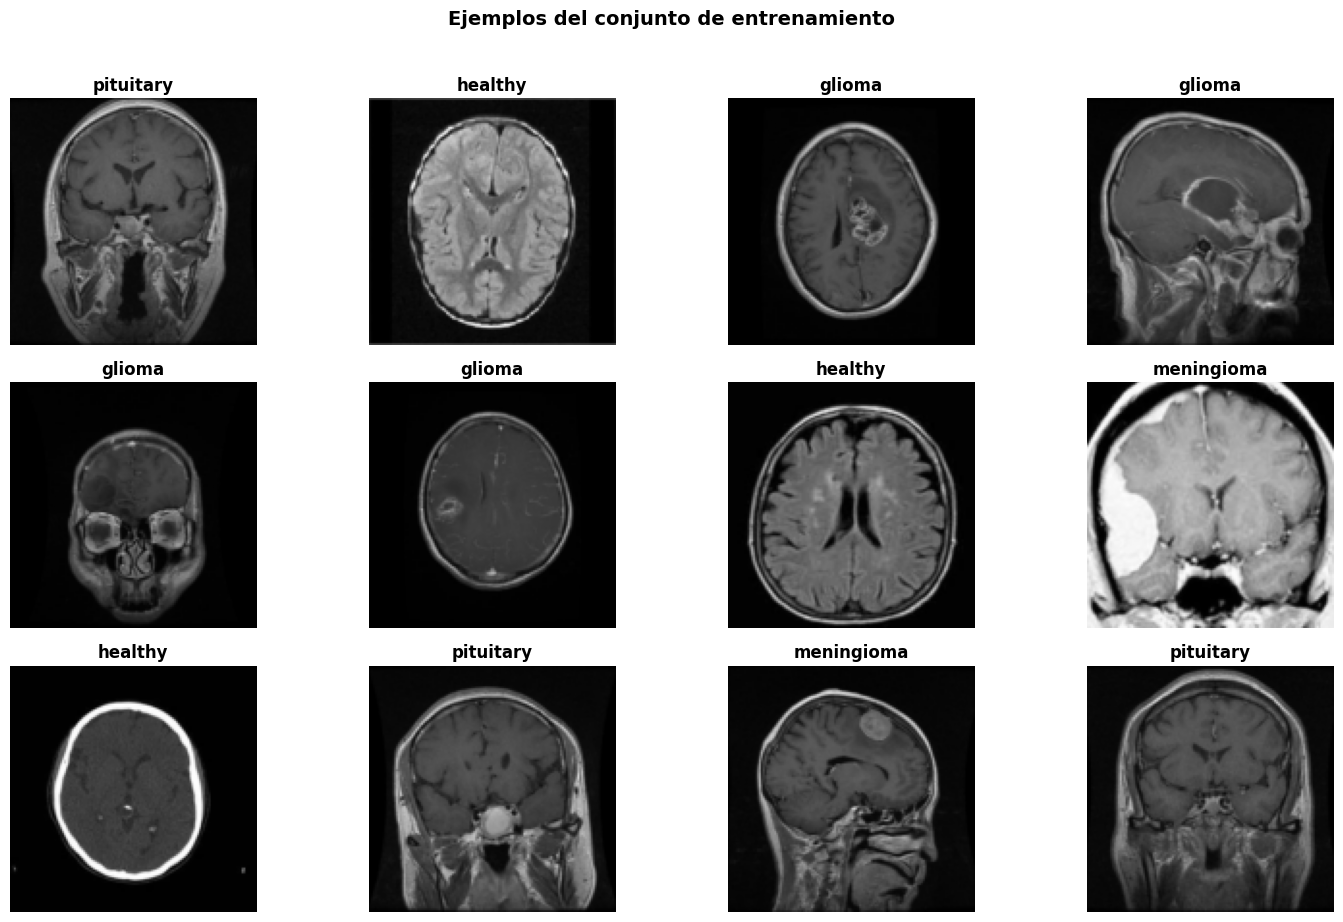

In [8]:
def visualize_samples(loader, class_names, num_samples=12):
    """
    Muestra un grid de imágenes del dataset con su etiqueta de clase.

    Extrae el primer batch del loader y grafica las primeras `num_samples`
    imágenes. Útil para inspección visual del pipeline de carga.

    Parámetros
    ----------
    loader      : DataLoader del cual tomar las imágenes.
    class_names : Lista de nombres de clase para las etiquetas del gráfico.
    num_samples : Número de imágenes a mostrar (debe ser múltiplo de 4).
    """
    cols = 4
    rows = num_samples // cols

    images, labels = next(iter(loader))

    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3))
    axes = axes.flatten()

    for i in range(min(num_samples, len(images))):
        # PyTorch: [C, H, W] → [H, W, C] para matplotlib
        img        = images[i].permute(1, 2, 0).numpy()
        label_name = class_names[labels[i].item()]
        axes[i].imshow(img)
        axes[i].set_title(f'{label_name}', fontsize=12, fontweight='bold')
        axes[i].axis('off')

    # Ocultar ejes vacíos si num_samples no llena el grid completo
    for i in range(num_samples, len(axes)):
        axes[i].axis('off')

    plt.suptitle('Ejemplos del conjunto de entrenamiento', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

visualize_samples(train_loader, class_names, num_samples=12)


## 6. Arquitectura CNN

### Diseño general

La red sigue el patrón clásico de CNN para clasificación:

```
Entrada (3×128×128)
    ↓
Bloque Conv 1  →  32 feature maps  →  MaxPool  →  64×64
    ↓
Bloque Conv 2  →  64 feature maps  →  MaxPool  →  32×32
    ↓
Bloque Conv 3  →  128 feature maps →  MaxPool  →  16×16
    ↓
Flatten  →  128×16×16 = 32 768 neuronas
    ↓
FC(256) → FC(128) → FC(4)   [logits]
```

### Decisiones de diseño

**Convoluciones dobles por bloque (`Conv → Conv → Pool`):** Aplicar dos convoluciones antes del pooling permite al modelo componer representaciones más ricas antes de reducir la resolución espacial. Es el mismo principio de los bloques de VGGNet.

**`BatchNorm2d` antes de la activación:** Normaliza la distribución de activaciones en cada mini-batch, lo que estabiliza el entrenamiento y permite usar learning rates más altos. También tiene un leve efecto regularizador.

**`Dropout2d(0.25)` en bloques convolucionales:** A diferencia del dropout estándar (que anula neuronas individuales), `Dropout2d` anula **feature maps completos**, lo que es más efectivo para datos espaciales porque los píxeles adyacentes están correlacionados.

**`Dropout(0.5)` en capas densas:** Las capas FC tienen muchos más parámetros y son más propensas a sobreajuste, de ahí el dropout más agresivo.

**Salida con logits crudos (sin softmax):** `CrossEntropyLoss` de PyTorch aplica `log_softmax` internamente de forma numéricamente estable. Aplicar softmax antes sería redundante e inestable en precisión float32.

**Cálculo de la dimensión del clasificador:** Con entrada `128×128` y tres `MaxPool2d(2,2)`: `128 → 64 → 32 → 16`. El flatten produce `128 × 16 × 16 = 32 768` valores.


In [9]:
class BrainTumorCNN(nn.Module):
    """
    CNN para clasificación de tumores cerebrales en 4 categorías.

    Arquitectura de 3 bloques convolucionales con profundidad creciente (32→64→128
    feature maps), seguida de capas fully-connected para la clasificación final.

    Cada bloque convolucional aplica: Conv → BN → ReLU → Conv → ReLU → MaxPool → Dropout2d

    Parámetros
    ----------
    num_classes : Número de clases de salida (default: 4).

    Forma de entrada esperada
    -------------------------
    Tensor de forma [batch_size, 3, 128, 128] con valores en [0, 1].

    Forma de salida
    ---------------
    Logits de forma [batch_size, num_classes]. Sin softmax aplicado;
    compatible directamente con nn.CrossEntropyLoss.
    """

    def __init__(self, num_classes: int = 4):
        super(BrainTumorCNN, self).__init__()

        # Bloque 1: extrae características de bajo nivel (bordes, texturas)
        # Entrada: [B, 3, 128, 128] → Salida: [B, 32, 64, 64]
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # padding=1 preserva resolución espacial
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),  # segunda conv antes de reducir resolución
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                            # reduce H y W a la mitad: 128→64
            nn.Dropout2d(0.25),                            # regularización espacial: anula feature maps completos
        )

        # Bloque 2: extrae características de nivel medio (formas, estructuras)
        # Entrada: [B, 32, 64, 64] → Salida: [B, 64, 32, 32]
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                            # 64→32
            nn.Dropout2d(0.25),
        )

        # Bloque 3: extrae características de alto nivel (patrones semánticos)
        # Entrada: [B, 64, 32, 32] → Salida: [B, 128, 16, 16]
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                            # 32→16
            nn.Dropout2d(0.25),
        )

        # Clasificador: 128 * 16 * 16 = 32 768 → 256 → 128 → num_classes
        # Tres MaxPool(2,2) sobre entrada 128×128: 128→64→32→16
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),  # logits crudos — CrossEntropyLoss aplica softmax internamente
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x


In [10]:
model = BrainTumorCNN(num_classes=NUM_CLASSES).to(DEVICE)

print("Arquitectura del modelo:")
print(model)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal de parámetros   : {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")


Arquitectura del modelo:
BrainTumorCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Dropout2d(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Dropout2d(p=0.25, inplace=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3

## 7. Configuración del Entrenamiento

### Función de pérdida: `CrossEntropyLoss`

Combina `LogSoftmax` + `NLLLoss` en una sola operación numéricamente estable. Espera **logits crudos** como entrada (no probabilidades), por eso el modelo no aplica softmax al final. Es el equivalente a `categorical_crossentropy` de Keras pero acepta índices enteros como etiquetas, no one-hot vectors.

### Optimizador: `Adam` (lr = 0.001)

Adam adapta el learning rate por parámetro usando momentos de primer y segundo orden del gradiente. Es la elección estándar para empezar: converge rápido y es robusto a la elección del learning rate inicial.

### Scheduler: `ReduceLROnPlateau`

Reduce el learning rate por un factor de 0.5 cuando `val_loss` no mejora durante `patience=3` épocas consecutivas. Esto permite al modelo hacer ajustes finos en la zona del mínimo sin quedar atrapado en oscilaciones.

### Early Stopping (manual)

Detiene el entrenamiento si `val_loss` no mejora durante `PATIENCE=5` épocas y restaura los pesos del mejor modelo. Previene el sobreajuste sin necesidad de entrenar el número máximo de épocas.


In [11]:
# Función de pérdida: logits → log_softmax + NLLLoss internamente
criterion = nn.CrossEntropyLoss()

# Optimizador Adam con learning rate inicial
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Scheduler: reduce LR a la mitad si val_loss no mejora en 3 épocas consecutivas
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-7
)

EPOCHS  = 20  # Máximo de épocas (el early stopping puede detener antes)
PATIENCE = 5  # Épocas sin mejora en val_loss antes de detener el entrenamiento

print("Configuración del entrenamiento:")
print(f"  Loss function : CrossEntropyLoss")
print(f"  Optimizer     : Adam  (lr inicial = 0.001)")
print(f"  Scheduler     : ReduceLROnPlateau  (factor=0.5, patience=3, min_lr=1e-7)")
print(f"  Épocas máx.   : {EPOCHS}")
print(f"  Early stopping: patience={PATIENCE}")


Configuración del entrenamiento:
  Loss function : CrossEntropyLoss
  Optimizer     : Adam  (lr inicial = 0.001)
  Scheduler     : ReduceLROnPlateau  (factor=0.5, patience=3, min_lr=1e-7)
  Épocas máx.   : 20
  Early stopping: patience=5


## 8. Bucle de Entrenamiento

A diferencia de Keras, PyTorch requiere que el loop de entrenamiento sea **explícito**. Esto es más verboso pero da control total sobre cada paso.

**Secuencia por batch (fase de entrenamiento):**
1. `model.train()` — activa `Dropout` y `BatchNorm` en modo entrenamiento.
2. `optimizer.zero_grad()` — limpia gradientes del paso anterior (en PyTorch los gradientes se **acumulan** por defecto).
3. Forward pass: `outputs = model(images)`.
4. Cálculo de pérdida: `loss = criterion(outputs, labels)`.
5. Backpropagation: `loss.backward()` — calcula ∂loss/∂param para todos los parámetros.
6. Actualización de pesos: `optimizer.step()`.

**Fase de validación:**
- `model.eval()` desactiva Dropout y usa estadísticos globales de BatchNorm.
- `torch.no_grad()` evita construir el grafo computacional, reduciendo uso de memoria y tiempo.


In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    Ejecuta una época completa de entrenamiento sobre el dataset de train.

    Activa el modo entrenamiento del modelo (dropout activo, batch norm en modo
    estadísticos del batch), procesa todos los batches y retorna las métricas
    promedio ponderadas por el tamaño real de cada batch.

    Parámetros
    ----------
    model     : Modelo PyTorch a entrenar.
    loader    : DataLoader del conjunto de entrenamiento.
    criterion : Función de pérdida (CrossEntropyLoss).
    optimizer : Optimizador (Adam).
    device    : Dispositivo de cómputo ('cuda', 'mps' o 'cpu').

    Retorna
    -------
    avg_loss : float — Pérdida promedio sobre todos los ejemplos del epoch.
    accuracy : float — Precisión promedio en [0, 1].
    """
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()          # Limpiar gradientes acumulados del paso anterior
        outputs = model(images)        # Forward pass → logits [batch, num_classes]
        loss = criterion(outputs, labels)
        loss.backward()                # Backpropagation: calcula ∂loss/∂param
        optimizer.step()               # Actualiza parámetros según el optimizador

        # Acumular métricas ponderadas por tamaño de batch (el último puede ser menor)
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)  # Clase con mayor logit = predicción
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    """
    Evalúa el modelo sobre un DataLoader sin actualizar pesos.

    Desactiva dropout y usa estadísticos globales de BatchNorm (modo eval).
    Usa torch.no_grad() para evitar construir el grafo computacional,
    reduciendo consumo de memoria y acelerando la inferencia.

    Parámetros
    ----------
    model     : Modelo PyTorch en modo eval.
    loader    : DataLoader del conjunto a evaluar (val o test).
    criterion : Función de pérdida.
    device    : Dispositivo de cómputo.

    Retorna
    -------
    avg_loss : float — Pérdida promedio.
    accuracy : float — Precisión promedio en [0, 1].
    """
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds    = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

    return running_loss / total, correct / total


In [13]:
# Diccionario para registrar métricas por época
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

# Estado para early stopping y checkpoint del mejor modelo
best_val_loss    = float('inf')
epochs_no_improve = 0
best_model_state  = None

print("Iniciando entrenamiento...")
print(f"Épocas máximas: {EPOCHS}  |  Early stopping patience: {PATIENCE}")
print("=" * 75)
print(f"{'Época':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7} | {'LR':>8}")
print("-" * 75)

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, DEVICE)

    # Scheduler: ajusta LR si val_loss no mejora
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    # Registrar métricas del epoch
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"{epoch:>6} | {train_loss:>10.4f} | {train_acc:>9.4f} | {val_loss:>8.4f} | {val_acc:>7.4f} | {current_lr:>8.2e}")

    # --- Early Stopping ---
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        # Guardar copia profunda del estado del modelo (no referencia)
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping en época {epoch}: sin mejora en val_loss por {PATIENCE} épocas consecutivas.")
            break

# Restaurar pesos del mejor checkpoint
model.load_state_dict(best_model_state)
print("\n" + "=" * 75)
print("Entrenamiento finalizado. Pesos restaurados al mejor checkpoint.")


Iniciando entrenamiento...
Épocas máximas: 20  |  Early stopping patience: 5
 Época | Train Loss | Train Acc | Val Loss | Val Acc |       LR
---------------------------------------------------------------------------
     1 |     0.8393 |    0.6573 |   0.5408 |  0.7797 | 1.00e-03
     2 |     0.5839 |    0.7663 |   0.4827 |  0.8120 | 1.00e-03
     3 |     0.5071 |    0.8017 |   0.4868 |  0.7873 | 1.00e-03
     4 |     0.4340 |    0.8302 |   0.3732 |  0.8557 | 1.00e-03
     5 |     0.3789 |    0.8558 |   0.4340 |  0.8167 | 1.00e-03
     6 |     0.3407 |    0.8735 |   0.3077 |  0.8613 | 1.00e-03
     7 |     0.2814 |    0.8944 |   0.3015 |  0.8936 | 1.00e-03
     8 |     0.2740 |    0.8975 |   0.2488 |  0.9022 | 1.00e-03
     9 |     0.2389 |    0.9138 |   0.3113 |  0.8841 | 1.00e-03
    10 |     0.2036 |    0.9223 |   0.1987 |  0.9278 | 1.00e-03
    11 |     0.1862 |    0.9321 |   0.2280 |  0.9212 | 1.00e-03
    12 |     0.1584 |    0.9433 |   0.2033 |  0.9354 | 1.00e-03
    13 |     0.

## 9. Visualización de las Métricas de Entrenamiento

Las curvas de aprendizaje son la herramienta principal para diagnosticar el comportamiento del modelo:

- **Brecha train/val pequeña**: el modelo generaliza bien.
- **Train mejora, val se estanca o empeora**: sobreajuste (overfitting).
- **Ambas métricas se estancan pronto**: subajuste (underfitting) o learning rate incorrecto.
- **Val mejor que train en primeras épocas**: normal cuando Dropout está activo solo en train.


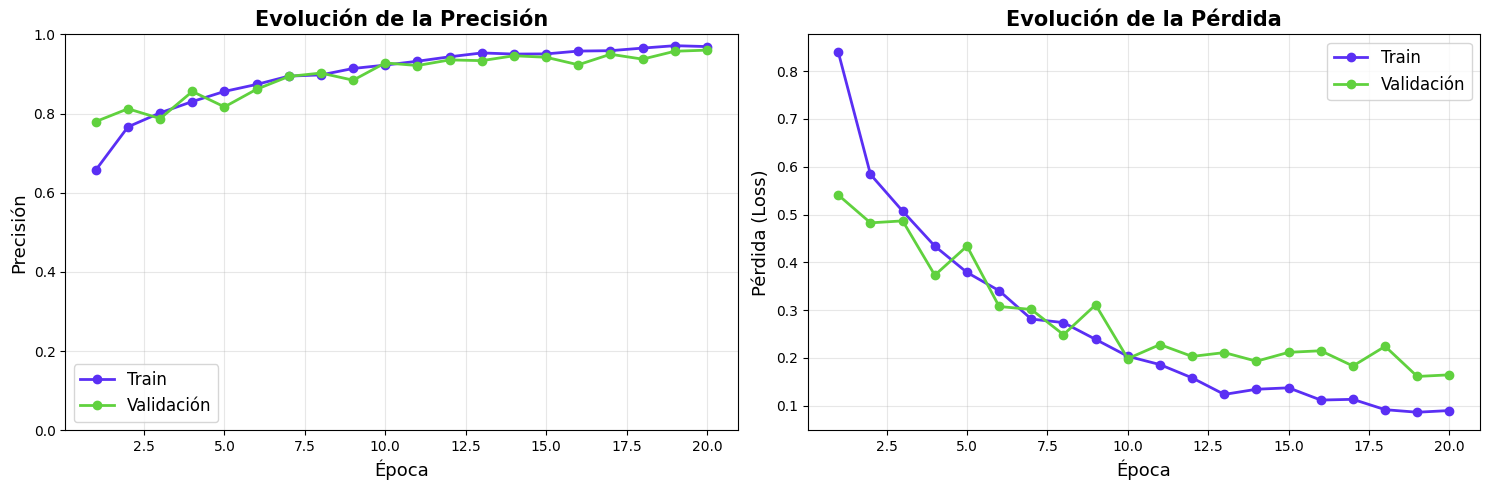


RESUMEN DEL ENTRENAMIENTO
  Épocas entrenadas        : 20
  Mejor época (val_acc)    : 20
  Train acc en mejor época : 0.9691
  Val   acc en mejor época : 0.9601
  Val   loss en mejor época: 0.1648


In [14]:
def visualize_training_history(history):
    """
    Grafica las curvas de precisión y pérdida del entrenamiento y validación.

    Muestra dos gráficas lado a lado: evolución de la accuracy y de la loss
    por época, diferenciando train y validación. Al final imprime un resumen
    con la mejor época según val_acc.

    Parámetros
    ----------
    history : dict con claves 'train_acc', 'val_acc', 'train_loss', 'val_loss',
              cada una con una lista de valores por época.
    """
    epochs_ran = len(history['train_acc'])
    x = range(1, epochs_ran + 1)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # --- Curva de precisión ---
    axes[0].plot(x, history['train_acc'], color='#5a2ff4', marker='o', linewidth=2, label='Train')
    axes[0].plot(x, history['val_acc'],   color='#60d13e', marker='o', linewidth=2, label='Validación')
    axes[0].set_xlabel('Época', fontsize=13)
    axes[0].set_ylabel('Precisión', fontsize=13)
    axes[0].set_title('Evolución de la Precisión', fontsize=15, fontweight='bold')
    axes[0].set_ylim([0, 1])
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=12)

    # --- Curva de pérdida ---
    axes[1].plot(x, history['train_loss'], color='#5a2ff4', marker='o', linewidth=2, label='Train')
    axes[1].plot(x, history['val_loss'],   color='#60d13e', marker='o', linewidth=2, label='Validación')
    axes[1].set_xlabel('Época', fontsize=13)
    axes[1].set_ylabel('Pérdida (Loss)', fontsize=13)
    axes[1].set_title('Evolución de la Pérdida', fontsize=15, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=12)

    plt.tight_layout()
    plt.show()

    best_epoch = int(np.argmax(history['val_acc']))
    print("\n" + "=" * 60)
    print("RESUMEN DEL ENTRENAMIENTO")
    print("=" * 60)
    print(f"  Épocas entrenadas        : {epochs_ran}")
    print(f"  Mejor época (val_acc)    : {best_epoch + 1}")
    print(f"  Train acc en mejor época : {history['train_acc'][best_epoch]:.4f}")
    print(f"  Val   acc en mejor época : {history['val_acc'][best_epoch]:.4f}")
    print(f"  Val   loss en mejor época: {history['val_loss'][best_epoch]:.4f}")
    print("=" * 60)

visualize_training_history(history)


## 10. Evaluación en el Conjunto de Prueba

El conjunto de test **nunca fue visto durante el entrenamiento ni el ajuste de hiperparámetros**, lo que lo convierte en la estimación más honesta del rendimiento real del modelo. Se evalúa usando los pesos del mejor checkpoint (restaurados al final del loop).


In [15]:
print("Evaluando modelo sobre el conjunto de prueba...")
print("=" * 60)

test_loss, test_acc = evaluate(model, test_loader, criterion, DEVICE)

print("RESULTADOS FINALES — CONJUNTO DE PRUEBA")
print("=" * 60)
print(f"  Pérdida   (Loss)    : {test_loss:.4f}")
print(f"  Precisión (Accuracy): {test_acc:.4f}  ({test_acc * 100:.2f}%)")
print("=" * 60)


Evaluando modelo sobre el conjunto de prueba...
RESULTADOS FINALES — CONJUNTO DE PRUEBA
  Pérdida   (Loss)    : 0.1469
  Precisión (Accuracy): 0.9544  (95.44%)


## 11. Matriz de Confusión y Métricas por Clase

La accuracy global puede ser engañosa en datasets con desbalance de clases. El reporte por clase incluye:

- **Precision**: de todas las predicciones de clase C, ¿cuántas eran realmente C? (minimiza falsos positivos)
- **Recall**: de todos los ejemplos reales de clase C, ¿cuántos se clasificaron correctamente? (minimiza falsos negativos)
- **F1-score**: media armónica de precision y recall; útil cuando ambas métricas importan.

La **matriz de confusión** permite identificar qué pares de clases el modelo confunde con más frecuencia, información clave para diagnóstico médico donde ciertos errores tienen mayor costo clínico que otros.


Generando predicciones sobre el conjunto de prueba...


/Users/I508111/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


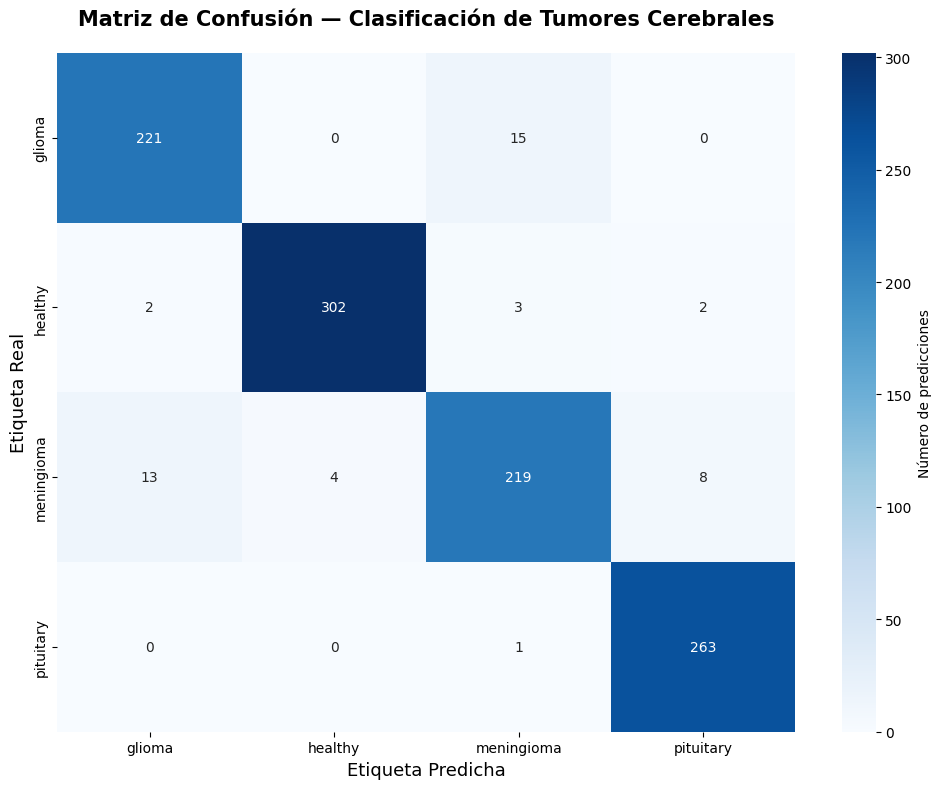


REPORTE DE CLASIFICACIÓN POR CLASE
              precision    recall  f1-score   support

      glioma     0.9364    0.9364    0.9364       236
     healthy     0.9869    0.9773    0.9821       309
  meningioma     0.9202    0.8975    0.9087       244
   pituitary     0.9634    0.9962    0.9795       264

    accuracy                         0.9544      1053
   macro avg     0.9517    0.9519    0.9517      1053
weighted avg     0.9542    0.9544    0.9542      1053



In [16]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("Generando predicciones sobre el conjunto de prueba...")

# Recolectar predicciones y etiquetas reales sobre todo el test set
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(DEVICE)
        outputs = model(images)
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

y_pred = np.array(all_preds)
y_true = np.array(all_labels)

# --- Matriz de confusión ---
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    cbar_kws={'label': 'Número de predicciones'}
)
plt.title('Matriz de Confusión — Clasificación de Tumores Cerebrales',
          fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Etiqueta Real', fontsize=13)
plt.xlabel('Etiqueta Predicha', fontsize=13)
plt.tight_layout()
plt.show()

# --- Reporte de clasificación por clase ---
print("\n" + "=" * 60)
print("REPORTE DE CLASIFICACIÓN POR CLASE")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


## 12. Guardado del Modelo

Se guarda un **checkpoint completo** que incluye no solo los pesos (`state_dict`) sino también los metadatos necesarios para reconstruir el modelo: número de clases, nombres de clase y tamaño de imagen esperado. Esto facilita la carga del modelo en otro entorno sin necesidad de redefinir los hiperparámetros manualmente.

> En PyTorch la práctica recomendada es guardar el `state_dict` y no el objeto modelo completo, ya que el segundo usa pickle y puede fallar si cambia la estructura del código.


In [17]:
model_path = 'brain_tumor_cnn_model_pytorch.pth'

torch.save({
    'model_state_dict': model.state_dict(),  # Pesos del modelo
    'num_classes'     : NUM_CLASSES,
    'class_names'     : class_names,
    'img_size'        : IMG_SIZE,
}, model_path)

print(f"Modelo guardado en: {model_path}")
print()
print("Para cargar el modelo en otro script:")
print(f"    checkpoint = torch.load('{model_path}')")
print( "    model = BrainTumorCNN(num_classes=checkpoint['num_classes'])")
print( "    model.load_state_dict(checkpoint['model_state_dict'])")
print( "    model.eval()")


Modelo guardado en: brain_tumor_cnn_model_pytorch.pth

Para cargar el modelo en otro script:
    checkpoint = torch.load('brain_tumor_cnn_model_pytorch.pth')
    model = BrainTumorCNN(num_classes=checkpoint['num_classes'])
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()


## 12. Conclusiones

Se implementó una CNN personalizada con arquitectura de tres bloques convolucionales seguida de capas densas de clasificación, usando PyTorch como framework principal. Mas información sobre la metodologia y resultados obtenidos se puede consultar en el reporte/articulo desarrollado como complemento de este Notebook.